# 1. **Environment setting and Data loading**

In [ ]:

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg in ['kaggle', 'plotly', 'folium', 'seaborn', 'scipy', 'openpyxl']:
    install(pkg)

print(' All dependencies installed.')

 All dependencies installed.


In [ ]:

!pip install kaggle -q

import os
import pandas as pd


DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d olistbr/brazilian-ecommerce -p data --unzip

def load_csv(file):
    path = os.path.join(DATA_DIR, file)

    if not os.path.exists(path):
        raise FileNotFoundError(f" Missing file: {file}")

    df = pd.read_csv(path)
    print(f" Loaded {file} → {df.shape}")
    return df

orders = load_csv("olist_orders_dataset.csv")
reviews = load_csv("olist_order_reviews_dataset.csv")
customers = load_csv("olist_customers_dataset.csv")
products = load_csv("olist_products_dataset.csv")

translation = load_csv("product_category_name_translation.csv")
sellers = load_csv("olist_sellers_dataset.csv")
payments = load_csv("olist_order_payments_dataset.csv")
order_items = load_csv("olist_order_items_dataset.csv")
geolocation = load_csv("olist_geolocation_dataset.csv")


print("\n DATA LOADING COMPLETE CHECK")

datasets = {
    "orders": orders,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "translation": translation,
    "sellers": sellers,
    "payments": payments,
    "order_items": items,
    "geolocation": geolocation
}

for name, df in datasets.items():
    if df is None:
        raise Exception(f" Dataset failed: {name}")
    print(f"{name}: OK → {df.shape}")

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 136MB/s]

 Loaded olist_orders_dataset.csv → (99441, 8)
 Loaded olist_order_reviews_dataset.csv → (99224, 7)
 Loaded olist_customers_dataset.csv → (99441, 5)
 Loaded olist_products_dataset.csv → (32951, 9)
 Loaded product_category_name_translation.csv → (71, 2)
 Loaded olist_sellers_dataset.csv → (3095, 4)
 Loaded olist_order_payments_dataset.csv → (103886, 5)
 Loaded olist_order_items_dataset.csv → (112650, 7)
 Loaded olist_geolocation_dataset.csv → (1000163, 5)

 DATA LOADING COMPLETE CHECK
orders: OK → (99441, 8)
reviews: OK → (99224, 7)
customers: OK → (99441, 5)
products: OK → (32951, 9)
translation: OK → (71, 2)
sellers: OK → (3095, 4)
payments: OK → (103886, 5)
order_items: OK → (112650, 7)
geolocation: OK → (1000163, 5)


# **Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np


date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")



orders_clean = orders[orders["order_status"] == "delivered"].copy()



orders_clean = orders_clean.drop_duplicates(subset="order_id")



if reviews is not None:
    reviews["review_creation_date"] = pd.to_datetime(
        reviews["review_creation_date"], errors="coerce"
    )

    reviews = reviews.sort_values("review_creation_date")


    reviews_clean = reviews.drop_duplicates(subset="order_id", keep="last")
else:
    reviews_clean = reviews



if order_items is not None:
    for col in ["price", "freight_value"]:
        if col in order_items.columns:
            order_items[col] = pd.to_numeric(order_items[col], errors="coerce")

if payments is not None:
    for col in ["payment_value", "payment_installments"]:
        if col in payments.columns:
            payments[col] = pd.to_numeric(payments[col], errors="coerce")



df = orders_clean.merge(reviews_clean, on="order_id", how="left") \
                 .merge(customers, on="customer_id", how="left")



if "review_score" in df.columns:
    df["review_score"] = df["review_score"].fillna(0)


df = df[df["order_delivered_customer_date"].notna()]



df["delay_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days



def classify_delay(x):
    if pd.isna(x):
        return "Unknown"
    elif x <= 0:
        return "On Time"
    elif x <= 5:
        return "Late"
    else:
        return "Super Late"

df["delivery_status"] = df["delay_days"].apply(classify_delay)



print("\n CLEANING COMPLETE SUMMARY")
print("-" * 40)
print("Final dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\n Delivery Status Distribution:")
print(df["delivery_status"].value_counts())


 CLEANING COMPLETE SUMMARY
----------------------------------------
Final dataset shape: (96470, 20)

Missing values:
 review_comment_title            85282
review_comment_message          57571
review_creation_date              646
review_id                         646
review_answer_timestamp           646
order_approved_at                  14
order_delivered_carrier_date        1
order_id                            0
order_purchase_timestamp            0
order_status                        0
dtype: int64

 Delivery Status Distribution:
delivery_status
On Time       89936
Super Late     3764
Late           2770
Name: count, dtype: int64


# **Importing Libraries**

In [ ]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})


COLORS = {
    'on_time': '#2ECC71',
    'late': '#F39C12',
    'super_late': '#E74C3C',
    'neutral': '#3498DB',
    'bg': '#F8F9FA',
}

print(' Imports complete.')

 Imports complete.


In [ ]:


orders     = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv')
reviews    = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')
customers  = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
products   = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
order_items= pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
category_t = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')

print('Raw row counts:')
for name, df in [
    ('orders', orders), ('reviews', reviews), ('customers', customers),
    ('products', products), ('order_items', order_items), ('category_translation', category_t)
]:
    print(f'  {name:25s}: {len(df):>7,} rows  |  {df.shape[1]} cols')

Raw row counts:
  orders                   :  99,441 rows  |  8 cols
  reviews                  :  99,224 rows  |  7 cols
  customers                :  99,441 rows  |  5 cols
  products                 :  32,951 rows  |  9 cols
  order_items              : 112,650 rows  |  7 cols
  category_translation     :      71 rows  |  2 cols


In [ ]:
orders.head(3) # first 3 rows of orders table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


---
## 2. Story 1 — Schema Builder: Joining the Tables <a id='2-schema-builder'></a>


In [ ]:
# Convert Order Date Columns to Datetime Format
DATE_COLS = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in DATE_COLS:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print('Date columns parsed.')
orders[DATE_COLS].dtypes

Date columns parsed.


,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [ ]:
# Clean and Deduplicate Customer Reviews
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')

reviews_dedup = (
    reviews
    .sort_values('review_creation_date')
    .drop_duplicates(subset='order_id', keep='last')
    [['order_id', 'review_score', 'review_creation_date', 'review_comment_title', 'review_comment_message']]
)

print(f'Reviews before dedup : {len(reviews):,}')
print(f'Reviews after  dedup : {len(reviews_dedup):,}')

Reviews before dedup : 99,224
Reviews after  dedup : 98,673


# **Build Master Dataset by Joining Orders, Reviews, and Customers**

In [ ]:

master = (
    orders
    .merge(reviews_dedup, on='order_id', how='left')
    .merge(customers,     on='customer_id', how='left')
)


assert len(master) == len(orders), (
    f'Row count mismatch! master={len(master):,}, orders={len(orders):,}'
)

print(f' Master dataset shape: {master.shape}')
print(f'   Unique orders      : {master["order_id"].nunique():,}')
master.head(3)

 Master dataset shape: (99441, 16)
   Unique orders      : 99,441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date,review_comment_title,review_comment_message,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,2017-10-11,NaN,"Não testei o produto ainda, mas ele veio corre...",7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,2018-08-08,Muito boa a loja,Muito bom o produto.,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,2018-08-18,NaN,NaN,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [ ]:
# Analyzing missing data in the master dataset
missing = master.isnull().sum()
missing_pct = (missing / len(master) * 100).round(2)

pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})[missing > 0]

,missing_count,missing_%
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98
review_score,768,0.77
review_creation_date,768,0.77
review_comment_title,87889,88.38
review_comment_message,58665,58.99


---
## 3. Story 2  : The "Real" Delay Calculator <a id='3-delay-calculator'></a>

**Formula:** `Days_Difference = order_estimated_delivery_date − order_delivered_customer_date`

- **Positive** → early / on time  
- **Negative** → late

**Status buckets:**
| Status | Condition |
|---|---|
| On Time | `Days_Difference >= 0` |
| Late | `-5 <= Days_Difference < 0` |
| Super Late | `Days_Difference < -5` |

In [ ]:
#  Filter delivered orders, compute delivery delay, classify delivery status, and summarize performance distribution
DELIVERED_STATUSES = {'delivered'}
df = master[master['order_status'].isin(DELIVERED_STATUSES)].copy()


df = df.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

print(f'Orders available for analysis : {len(df):,}')
print(f'Excluded (not delivered / missing dates) : {len(master) - len(df):,}')

df['Days_Difference'] = (
    df['order_estimated_delivery_date'] - df['order_delivered_customer_date']
).dt.days

def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

df['Delivery_Status'] = df['Days_Difference'].apply(classify_delivery)


status_counts = df['Delivery_Status'].value_counts()
status_pct    = (status_counts / len(df) * 100).round(2)

summary_df = pd.DataFrame({
    'Count': status_counts,
    'Percentage (%)': status_pct
})
print('\nDelivery Status Distribution:')
print(summary_df)

Orders available for analysis : 96,470
Excluded (not delivered / missing dates) : 2,971

Delivery Status Distribution:
                 Count  Percentage (%)
Delivery_Status                       
On Time          88644           91.89
Super Late        4211            4.37
Late              3615            3.75


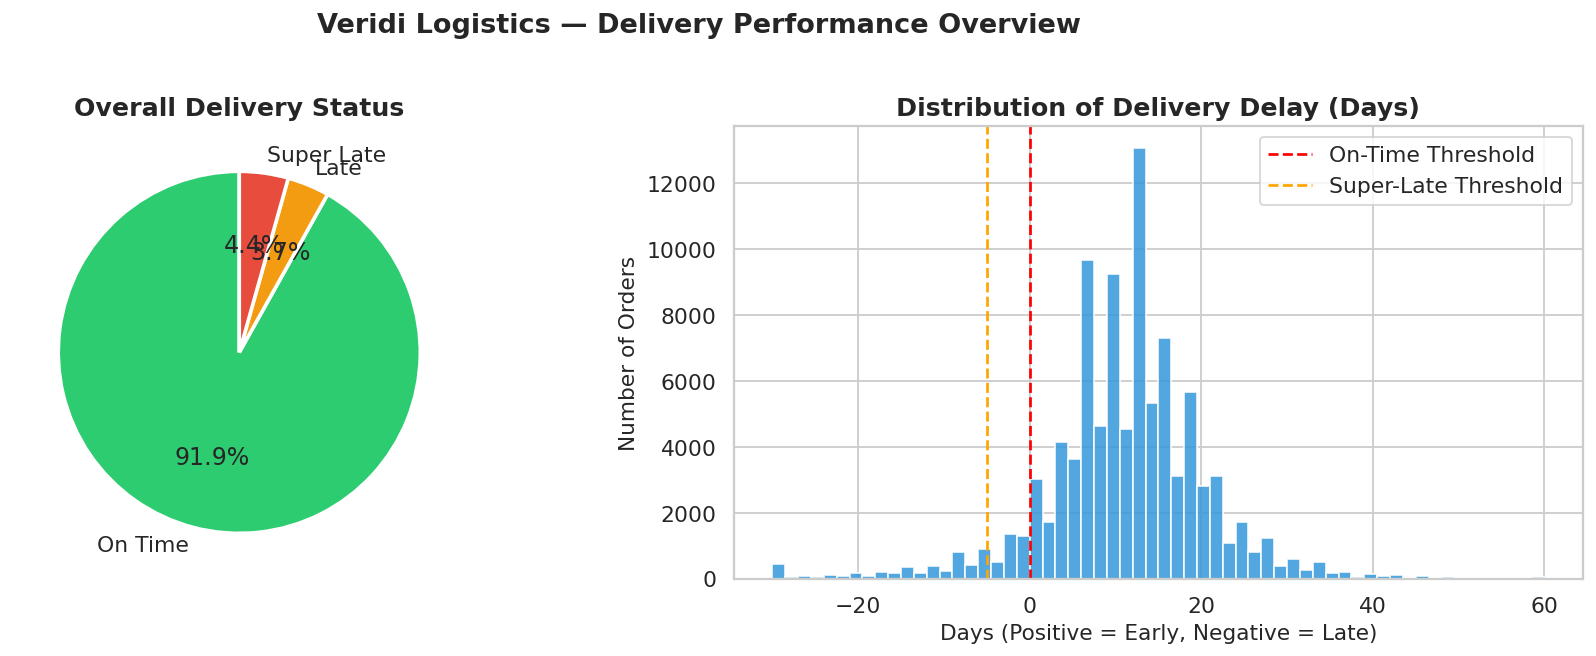


 Median delay: 11.0 days
 Mean delay  : 10.9 days


In [ ]:
#  Plot delivery status breakdown and delivery delay distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status_order = ['On Time', 'Late', 'Super Late']
palette_map  = [COLORS['on_time'], COLORS['late'], COLORS['super_late']]

wedge_sizes = [status_counts.get(s, 0) for s in status_order]
axes[0].pie(
    wedge_sizes,
    labels=status_order,
    autopct='%1.1f%%',
    colors=palette_map,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title('Overall Delivery Status', fontweight='bold')

axes[1].hist(
    df['Days_Difference'].clip(-30, 60),
    bins=60,
    color=COLORS['neutral'],
    edgecolor='white',
    alpha=0.85,
)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='On-Time Threshold')
axes[1].axvline(-5, color='orange', linestyle='--', linewidth=1.5, label='Super-Late Threshold')
axes[1].set_xlabel('Days (Positive = Early, Negative = Late)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Distribution of Delivery Delay (Days)', fontweight='bold')
axes[1].legend()

plt.suptitle('Veridi Logistics — Delivery Performance Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_delay_distribution.png', bbox_inches='tight')
plt.show()
print(f'\n Median delay: {df["Days_Difference"].median():.1f} days')
print(f' Mean delay  : {df["Days_Difference"].mean():.1f} days')

---
## 4. Story 3 — Geographic Heatmap <a id='4-geographic-heatmap'></a>

**Goal:** Identify which Brazilian states have the highest proportion of late deliveries.

In [ ]:
# Calculate late deliveries and summarize performance by state
df['Is_Late'] = df['Delivery_Status'].isin(['Late', 'Super Late']).astype(int)

state_stats = (
    df
    .groupby('customer_state')
    .agg(
        total_orders      = ('order_id', 'count'),
        late_orders       = ('Is_Late', 'sum'),
        avg_review_score  = ('review_score', 'mean'),
        avg_delay_days    = ('Days_Difference', 'mean'),
    )
    .reset_index()
)

state_stats['late_pct'] = (
    state_stats['late_orders'] / state_stats['total_orders'] * 100
).round(2)

state_stats = state_stats.sort_values('late_pct', ascending=False)
print('Top 10 States by Late Delivery %:')
state_stats.head(10)

Top 10 States by Late Delivery %:


,customer_state,total_orders,late_orders,avg_review_score,avg_delay_days,late_pct
1,AL,397,95,3.847716,7.707809,23.93
9,MA,717,141,3.832865,8.571827,19.67
16,PI,476,76,3.993631,10.306723,15.97
5,CE,1279,196,3.944226,9.804535,15.32
24,SE,335,51,3.907186,9.020896,15.22
4,BA,3256,457,3.929700,9.794533,14.04
18,RJ,12350,1664,3.965850,10.761215,13.47
26,TO,274,35,4.153846,11.131387,12.77
13,PA,946,117,3.914255,13.066596,12.37
7,ES,1995,244,4.078720,9.496241,12.23


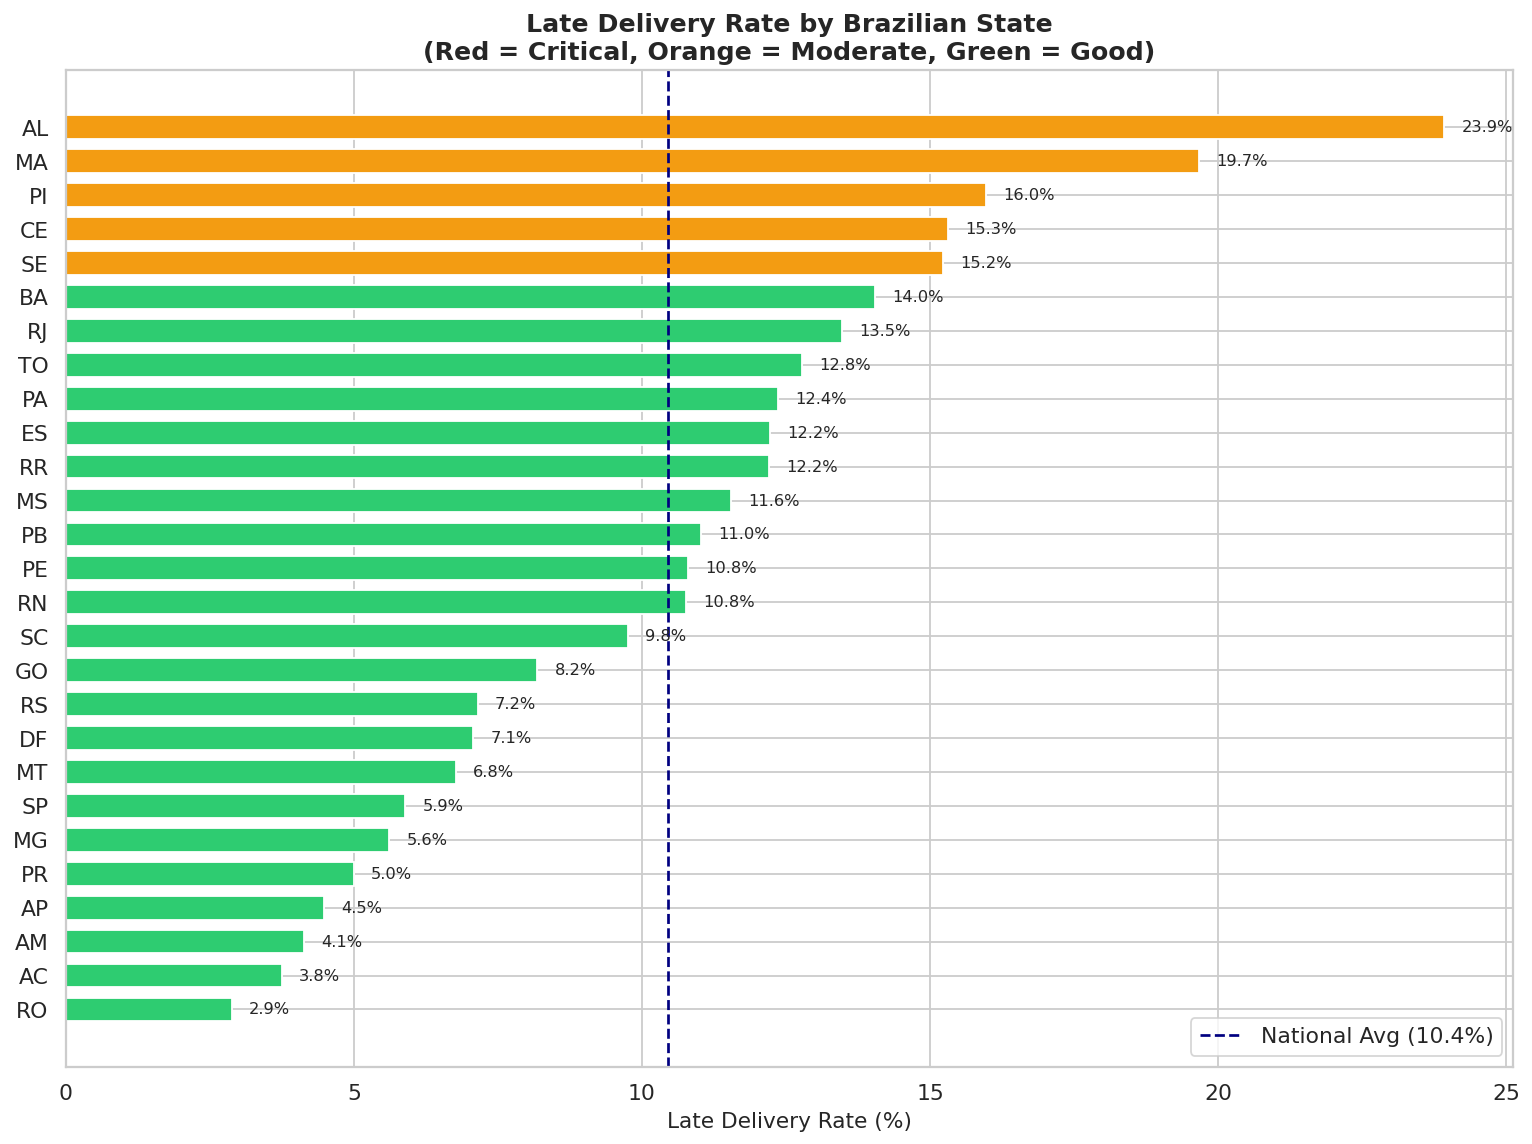

In [ ]:
#  Visualize late delivery rate by state with performance levels
fig, ax = plt.subplots(figsize=(12, 9))

colors = [
    COLORS['super_late'] if p >= 30 else COLORS['late'] if p >= 15 else COLORS['on_time']
    for p in state_stats['late_pct']
]

bars = ax.barh(
    state_stats['customer_state'],
    state_stats['late_pct'],
    color=colors,
    edgecolor='white',
    height=0.7,
)


for bar, val in zip(bars, state_stats['late_pct']):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=9,
    )

ax.axvline(state_stats['late_pct'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'National Avg ({state_stats["late_pct"].mean():.1f}%)')

ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Brazilian State\n(Red = Critical, Orange = Moderate, Green = Good)',
             fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart_geo_late_pct.png', bbox_inches='tight')
plt.show()

In [ ]:
#  Display late delivery rate across Brazilian states using a choropleth map

BRAZIL_GEOJSON = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

fig_map = px.choropleth(
    state_stats,
    geojson=BRAZIL_GEOJSON,
    locations='customer_state',
    featureidkey='properties.sigla',
    color='late_pct',
    color_continuous_scale='RdYlGn_r',
    range_color=[0, state_stats['late_pct'].max()],
    hover_data={
        'total_orders': ':,',
        'late_orders': ':,',
        'late_pct': ':.1f',
        'avg_review_score': ':.2f',
    },
    labels={
        'late_pct': 'Late Rate (%)',
        'customer_state': 'State',
        'avg_review_score': 'Avg Review',
    },
    title='  Brazil — Late Delivery Heatmap by State',
)

fig_map.update_geos(
    fitbounds='locations',
    visible=False,
    showcoastlines=True,
    coastlinecolor='gray',
)
fig_map.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    height=550,
)

fig_map.show()

In [ ]:
# Compare late delivery rates between core and remote states
CORE_STATES   = ['SP', 'RJ', 'MG', 'ES', 'PR', 'SC', 'RS']
REMOTE_STATES = [s for s in state_stats['customer_state'] if s not in CORE_STATES]

core_avg   = state_stats[state_stats['customer_state'].isin(CORE_STATES)]['late_pct'].mean()
remote_avg = state_stats[state_stats['customer_state'].isin(REMOTE_STATES)]['late_pct'].mean()

print(' Geographic Insight:')
print(f'   Core states  (near São Paulo hub) avg late rate : {core_avg:.1f}%')
print(f'   Remote states                     avg late rate : {remote_avg:.1f}%')
print(f'   Remote states are {remote_avg/core_avg:.1f}x more likely to receive late deliveries.')

 Geographic Insight:
   Core states  (near São Paulo hub) avg late rate : 8.4%
   Remote states                     avg late rate : 11.1%
   Remote states are 1.3x more likely to receive late deliveries.


In [ ]:
print("Displaying the first few rows of the state_stats DataFrame:")
display(state_stats.head())

print("\nColumns available in state_stats:")
display(state_stats.columns)

Displaying the first few rows of the state_stats DataFrame:


,customer_state,total_orders,late_orders,avg_review_score,avg_delay_days,late_pct
1,AL,397,95,3.847716,7.707809,23.93
9,MA,717,141,3.832865,8.571827,19.67
16,PI,476,76,3.993631,10.306723,15.97
5,CE,1279,196,3.944226,9.804535,15.32
24,SE,335,51,3.907186,9.020896,15.22



Columns available in state_stats:


Index(['customer_state', 'total_orders', 'late_orders', 'avg_review_score',
       'avg_delay_days', 'late_pct'],
      dtype='object')

---
## 5. Story 4 — Sentiment Correlation <a id='5-sentiment-correlation'></a>

**Goal:** Prove that late deliveries cause negative reviews.

In [ ]:
# Analyze customer review scores by delivery status
sentiment_by_status = (
    df.dropna(subset=['review_score'])
    .groupby('Delivery_Status')
    .agg(
        avg_score  = ('review_score', 'mean'),
        count      = ('review_score', 'count'),
        pct_1star  = ('review_score', lambda x: (x == 1).mean() * 100),
    )
    .reindex(['On Time', 'Late', 'Super Late'])
    .round(2)
)

print('Average Review Score by Delivery Status:')
print(sentiment_by_status)

Average Review Score by Delivery Status:
                 avg_score  count  pct_1star
Delivery_Status                             
On Time               4.29  88163       6.59
Late                  3.46   3568      21.97
Super Late            1.78   4093      67.36


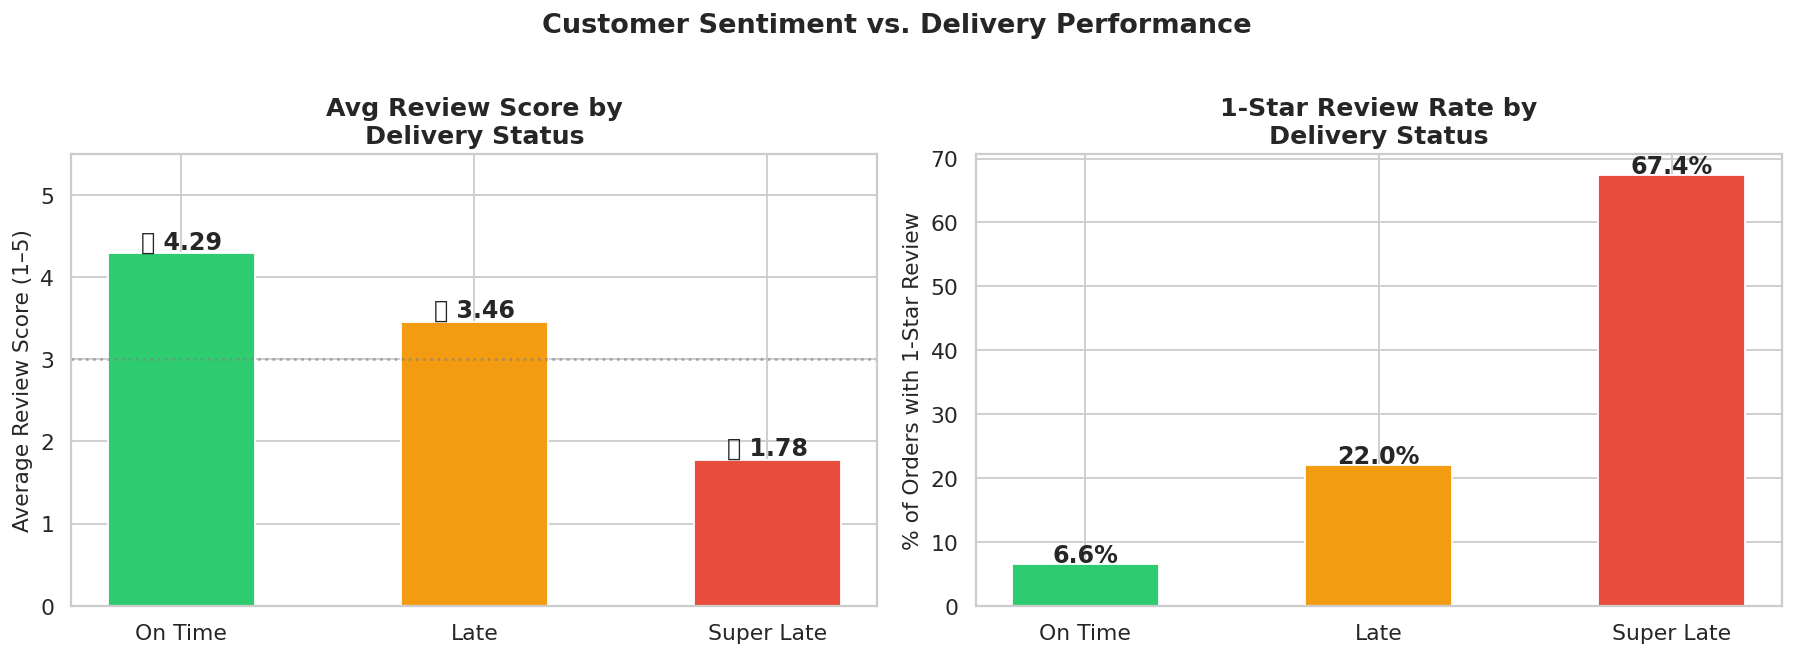

In [ ]:
# Visualize customer sentiment (review scores and 1-star rate) by delivery status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


bars2 = axes[0].bar(
    sentiment_by_status.index,
    sentiment_by_status['avg_score'],
    color=[COLORS['on_time'], COLORS['late'], COLORS['super_late']],
    edgecolor='white',
    width=0.5,
)
axes[0].set_ylim(0, 5.5)
axes[0].axhline(3.0, color='gray', linestyle=':', alpha=0.6)
for bar, val in zip(bars2, sentiment_by_status['avg_score']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'⭐ {val:.2f}',
        ha='center', fontweight='bold',
    )
axes[0].set_ylabel('Average Review Score (1–5)')
axes[0].set_title('Avg Review Score by\nDelivery Status', fontweight='bold')


axes[1].bar(
    sentiment_by_status.index,
    sentiment_by_status['pct_1star'],
    color=[COLORS['on_time'], COLORS['late'], COLORS['super_late']],
    edgecolor='white',
    width=0.5,
)
axes[1].set_ylabel('% of Orders with 1-Star Review')
axes[1].set_title('1-Star Review Rate by\nDelivery Status', fontweight='bold')
for bar, val in zip(axes[1].patches, sentiment_by_status['pct_1star']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', fontweight='bold',
    )

plt.suptitle('Customer Sentiment vs. Delivery Performance', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_sentiment_by_status.png', bbox_inches='tight')
plt.show()

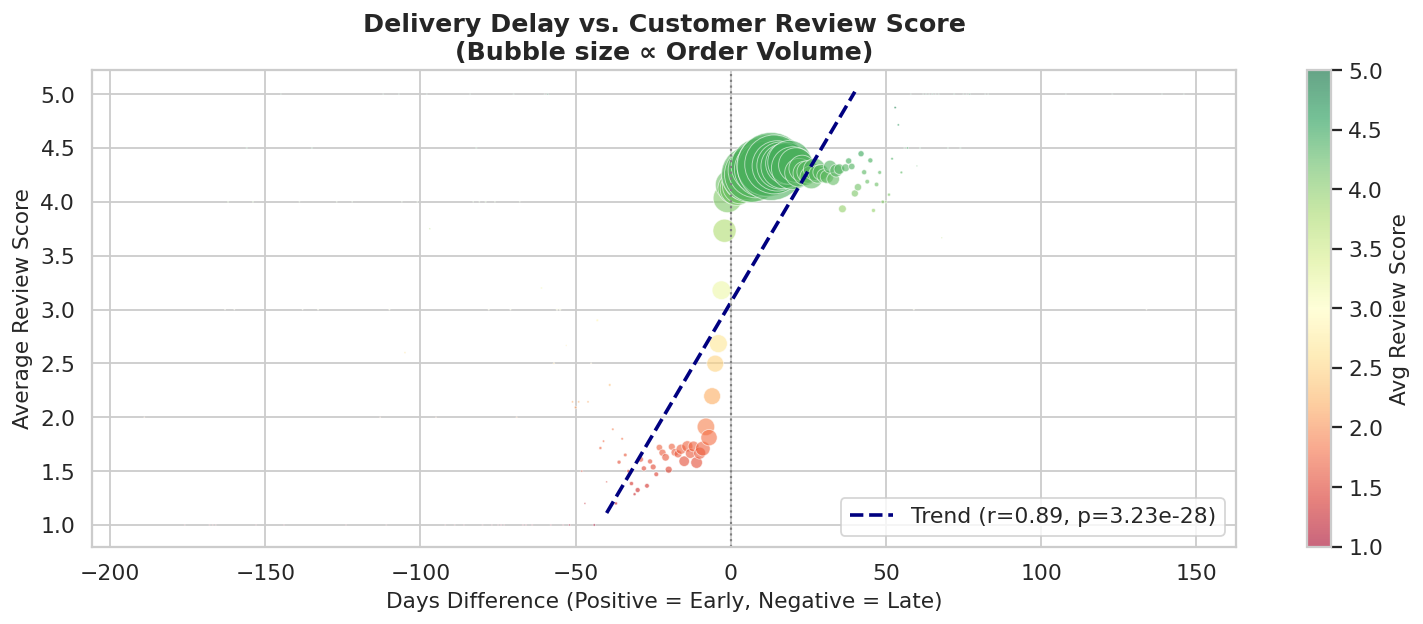


 Pearson r = 0.887 | p-value = 3.23e-28
   → A positive r confirms: earlier deliveries = higher review scores.


In [ ]:

# Analyze relationship between delivery delay and customer review score with regression and scatter plot
df_scored = df.dropna(subset=['review_score', 'Days_Difference']).copy()


df_scored['delay_bin'] = pd.cut(
    df_scored['Days_Difference'].clip(-40, 40),
    bins=range(-40, 45, 5),
    labels=[f'{i} to {i+5}d' for i in range(-40, 40, 5)],
)

bin_agg = (
    df_scored
    .groupby('Days_Difference')
    .agg(avg_score=('review_score', 'mean'), n=('review_score', 'count'))
    .reset_index()
)

fig2, ax2 = plt.subplots(figsize=(12, 5))

scatter = ax2.scatter(
    bin_agg['Days_Difference'],
    bin_agg['avg_score'],
    c=bin_agg['avg_score'],
    cmap='RdYlGn',
    alpha=0.6,
    s=bin_agg['n'] / 5,
    vmin=1, vmax=5,
    edgecolors='white',
    linewidths=0.5,
)


mask = bin_agg['Days_Difference'].between(-40, 40)
x_fit = bin_agg.loc[mask, 'Days_Difference']
y_fit = bin_agg.loc[mask, 'avg_score']
m, b, r, p, _ = stats.linregress(x_fit, y_fit)
ax2.plot(x_fit, m * x_fit + b, color='navy', linewidth=2, linestyle='--',
         label=f'Trend (r={r:.2f}, p={p:.2e})')

ax2.axvline(0, color='gray', linestyle=':', linewidth=1.2)
ax2.set_xlabel('Days Difference (Positive = Early, Negative = Late)')
ax2.set_ylabel('Average Review Score')
ax2.set_title('Delivery Delay vs. Customer Review Score\n(Bubble size ∝ Order Volume)',
              fontweight='bold')
ax2.legend()
plt.colorbar(scatter, ax=ax2, label='Avg Review Score')
plt.tight_layout()
plt.savefig('chart_delay_vs_review.png', bbox_inches='tight')
plt.show()

print(f'\n Pearson r = {r:.3f} | p-value = {p:.2e}')
print('   → A positive r confirms: earlier deliveries = higher review scores.')

---
## 6. Bonus — English Category Translation <a id='6-category-translation'></a>

**Goal:** Translate Portuguese product categories to English and analyse which categories suffer the most delays.

In [ ]:

# Translate product categories to English and merge category information into the main dataset
products_en = products.merge(
    category_t,
    on='product_category_name',
    how='left',
)

products_en['category_en'] = products_en['product_category_name_english'].fillna(
    products_en['product_category_name']
).str.replace('_', ' ').str.title()

order_category = (
    order_items
    .merge(products_en[['product_id', 'category_en']], on='product_id', how='left')
    .groupby('order_id')['category_en']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
    .reset_index()
)

df = df.merge(order_category, on='order_id', how='left')
df['category_en'] = df['category_en'].fillna('Unknown')

print(f' Category column added. Unique categories: {df["category_en"].nunique()}')

 Category column added. Unique categories: 74


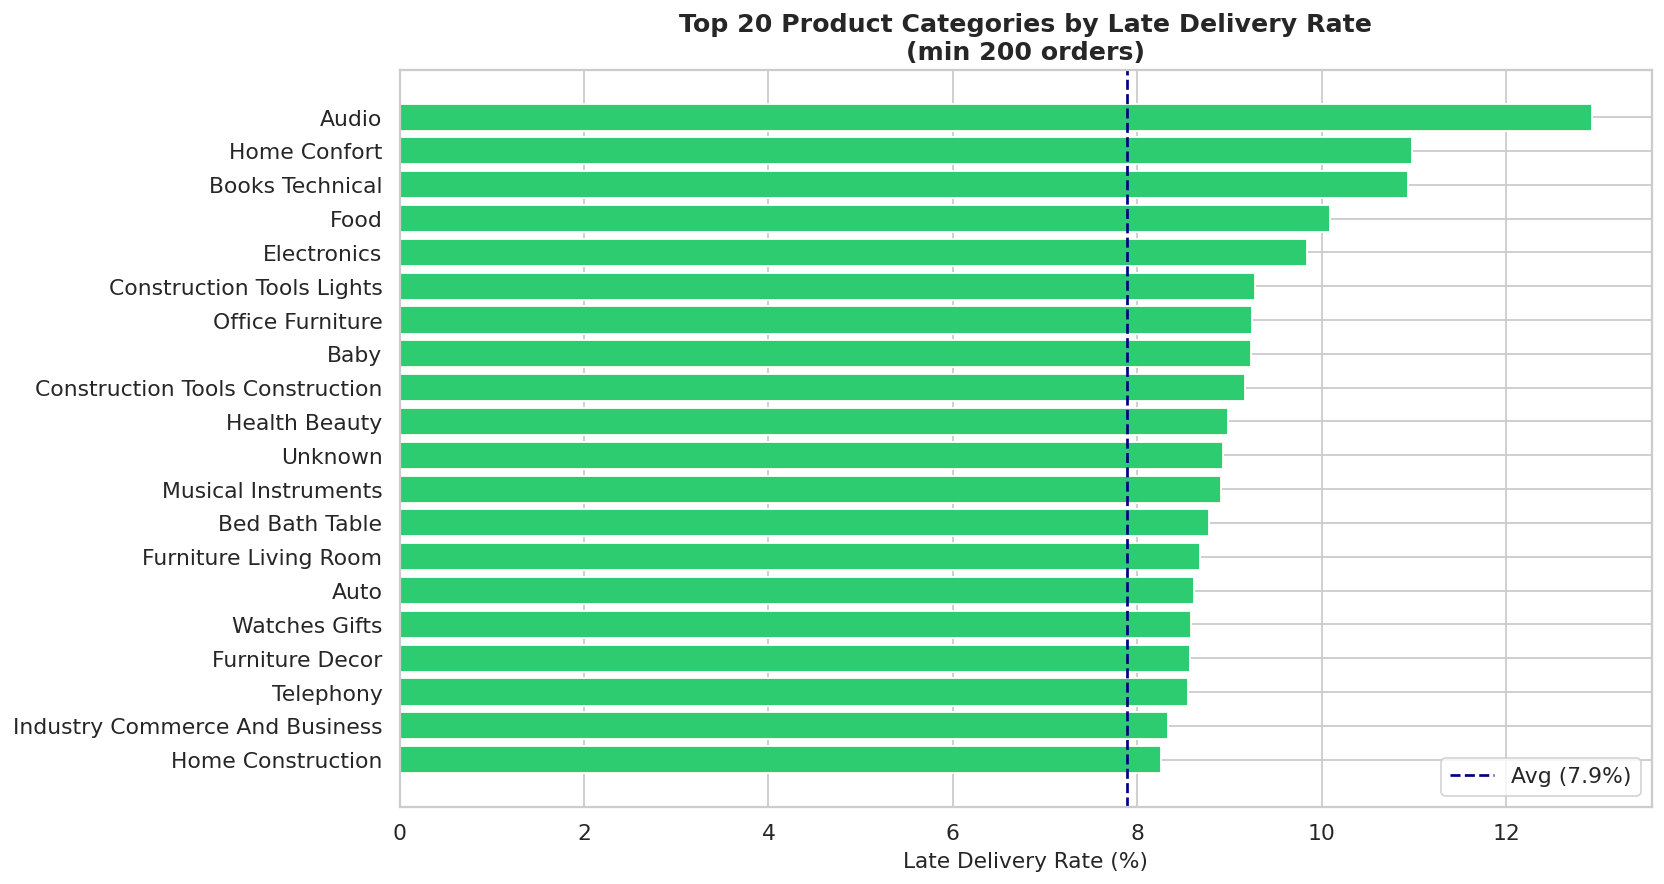

In [ ]:
# Calculate and visualize late delivery rate by product category

cat_stats = (
    df.groupby('category_en')
    .agg(
        total   = ('order_id', 'count'),
        late    = ('Is_Late', 'sum'),
        avg_rev = ('review_score', 'mean'),
    )
    .reset_index()
)
cat_stats['late_pct'] = (cat_stats['late'] / cat_stats['total'] * 100).round(2)

cat_stats_filtered = cat_stats[cat_stats['total'] >= 200].sort_values('late_pct', ascending=False)

top_n = 20
fig3, ax3 = plt.subplots(figsize=(13, 7))
data_plot = cat_stats_filtered.head(top_n)

bar_colors = [
    COLORS['super_late'] if p >= 30 else COLORS['late'] if p >= 15 else COLORS['on_time']
    for p in data_plot['late_pct']
]

ax3.barh(data_plot['category_en'], data_plot['late_pct'], color=bar_colors, edgecolor='white')
ax3.axvline(
    cat_stats_filtered['late_pct'].mean(),
    color='navy', linestyle='--', linewidth=1.5,
    label=f'Avg ({cat_stats_filtered["late_pct"].mean():.1f}%)'
)
ax3.set_xlabel('Late Delivery Rate (%)')
ax3.set_title(f'Top {top_n} Product Categories by Late Delivery Rate\n(min 200 orders)',
              fontweight='bold')
ax3.legend()
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig('chart_category_late.png', bbox_inches='tight')
plt.show()

---
## 7. My Choice    "Revenue at Risk" Analysis <a id='7-candidates-choice'></a>

###  **Business Justification**

> Simply knowing *that* deliveries are late is not enough to prioritise action. The CEO needs to know **where money is being lost**. A state with a 40% late rate but only 50 orders is less urgent than a state with a 20% late rate and 5,000 orders. By combining **late rate × order volume × average order value**, we create a single "Revenue at Risk" metric that tells operations teams exactly where to allocate resources first.

This analysis also surfaces which **product categories** generate the most financial exposure, enabling targeted SLA renegotiations with carriers.

In [ ]:
# Create delivery delay metrics and calculate revenue at risk by state

import pandas as pd

date_cols = [
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


df["delay_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days


df["delivery_status"] = df["delay_days"].apply(
    lambda x: "On Time" if pd.notna(x) and x <= 0
    else "Late" if pd.notna(x) and x <= 5
    else "Super Late" if pd.notna(x)
    else "Unknown"
)


df["Is_Late"] = df["delivery_status"].isin(["Late", "Super Late"]).astype(int)


order_revenue = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(order_value=("price", "sum"))
)

df = df.merge(order_revenue, on="order_id", how="left")
df["order_value"] = df["order_value"].fillna(0)


state_total = (
    df.groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("order_value", "sum")
    )
    .reset_index()
)


late_df = df[df["Is_Late"] == 1]

state_late = (
    late_df.groupby("customer_state")
    .agg(
        late_orders=("order_id", "count"),
        late_revenue=("order_value", "sum")
    )
    .reset_index()
)


state_rev = state_total.merge(state_late, on="customer_state", how="left")
state_rev[["late_orders", "late_revenue"]] = state_rev[["late_orders", "late_revenue"]].fillna(0)


state_rev["late_pct"] = (state_rev["late_orders"] / state_rev["total_orders"] * 100).round(1)
state_rev["revenue_at_risk_%"] = (state_rev["late_revenue"] / state_rev["total_revenue"] * 100).round(1)


state_rev = state_rev.sort_values("late_revenue", ascending=False)

print("TOP 10 STATES BY REVENUE AT RISK\n")

state_rev[
    [
        "customer_state",
        "total_orders",
        "late_orders",
        "late_pct",
        "total_revenue",
        "late_revenue",
        "revenue_at_risk_%"
    ]
].head(10)

TOP 10 STATES BY REVENUE AT RISK



,customer_state,total_orders,late_orders,late_pct,total_revenue,late_revenue,revenue_at_risk_%
25,SP,40494,1820,4.5,5066562.98,269383.42,5.3
18,RJ,12350,1495,12.1,1759651.13,215415.46,12.2
10,MG,11354,519,4.6,1552481.83,75837.49,4.9
4,BA,3256,396,12.2,493584.14,62058.74,12.6
22,RS,5344,325,6.1,728718.47,43968.03,6.0
23,SC,3546,291,8.2,507012.13,38103.95,7.5
7,ES,1995,214,10.7,268643.45,34907.68,13.0
5,CE,1279,176,13.8,219757.38,30604.18,13.9
17,PR,4923,199,4.0,666063.51,29504.05,4.4
15,PE,1593,153,9.6,251889.49,26746.30,10.6


In [ ]:
# Visualize revenue at risk vs late delivery rate by state using a bubble chart
import plotly.express as px

fig_bub = px.scatter(
    state_rev,

    x='late_pct',
    y='late_revenue',
    size='total_orders',


    color='revenue_at_risk_%',
    hover_name='customer_state',
    color_continuous_scale='Reds',

    labels={
        'late_pct': 'Late Delivery Rate (%)',
        'late_revenue': 'Revenue at Risk (R$)',
        'revenue_at_risk_%': 'Revenue at Risk (%)',
        'total_orders': 'Total Orders',
    },

    title='💰 Revenue at Risk by State (Bubble Size = Demand Volume)',
    height=550
)


fig_bub.update_traces(
    marker=dict(
        opacity=0.85,
        line=dict(width=0.8, color='white')
    )
)

fig_bub.update_layout(
    margin=dict(t=60),
    xaxis_title="Late Delivery Rate (%)",
    yaxis_title="Revenue at Risk (R$)"
)

fig_bub.show()

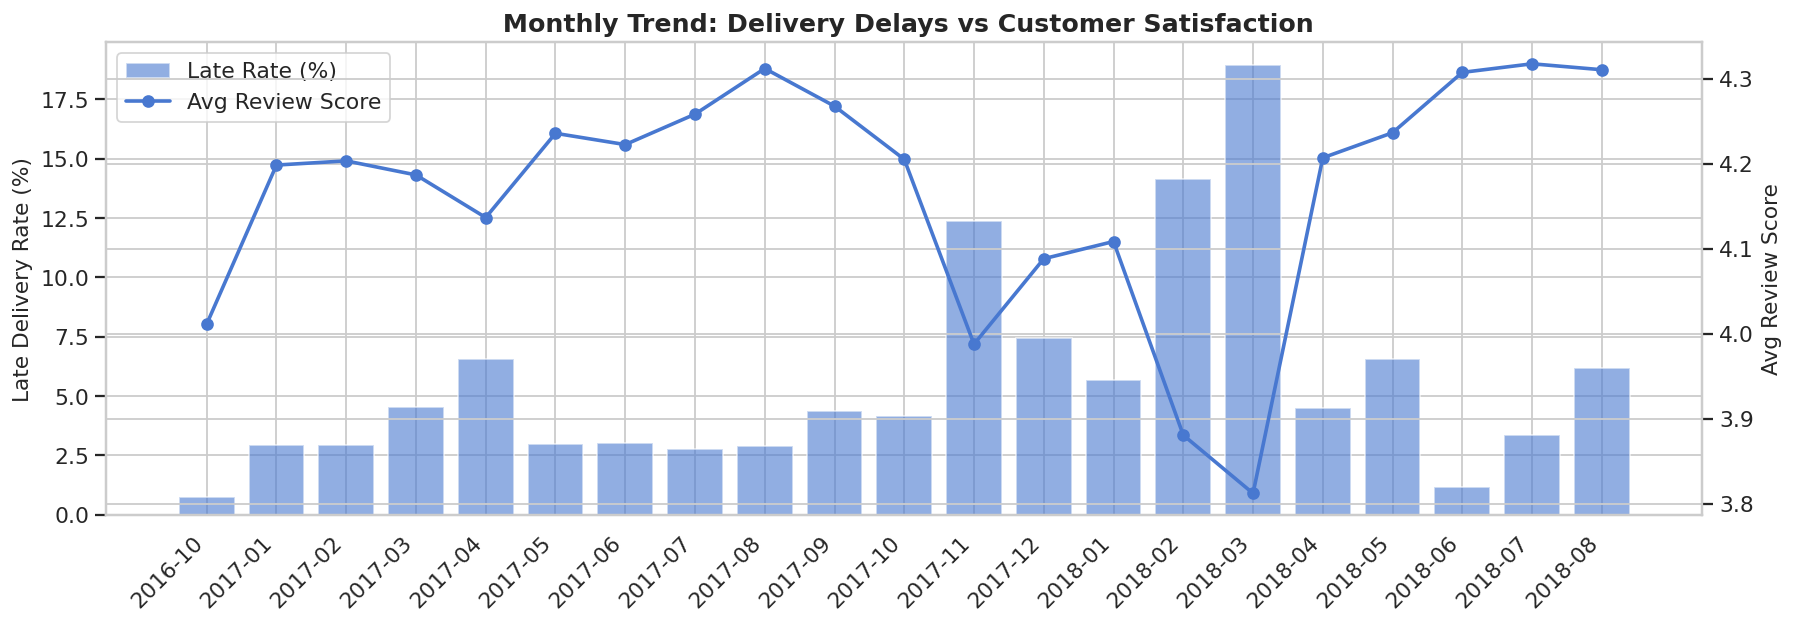

In [ ]:
# Analyze monthly trends of late delivery rate and average customer review score
import matplotlib.pyplot as plt


df['order_month'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce') \
                      .dt.to_period('M').astype(str)


monthly = (
    df.groupby('order_month')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('Is_Late', 'sum'),
        avg_review_score=('review_score', 'mean')
    )
    .reset_index()
)


monthly['late_pct'] = (
    monthly['late_orders'] / monthly['total_orders'] * 100
).round(2)

monthly = monthly[monthly['total_orders'] >= 50]


fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()


ax1.bar(
    monthly['order_month'],
    monthly['late_pct'],
    alpha=0.6,
    label='Late Rate (%)'
)


ax2.plot(
    monthly['order_month'],
    monthly['avg_review_score'],
    marker='o',
    linewidth=2,
    label='Avg Review Score'
)


ax1.set_xticklabels(monthly['order_month'], rotation=45, ha='right')

ax1.set_ylabel('Late Delivery Rate (%)')
ax2.set_ylabel('Avg Review Score')

ax1.set_title(' Monthly Trend: Delivery Delays vs Customer Satisfaction', fontweight='bold')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
 # Generate executive summary of delivery performance, customer ratings, and revenue risk
import numpy as np


total_orders = len(df)
overall_late = df["Is_Late"].mean() * 100


on_time_score = df.loc[df["delivery_status"] == "On Time", "review_score"].mean()
late_score = df.loc[df["delivery_status"] == "Late", "review_score"].mean()
super_late_score = df.loc[df["delivery_status"] == "Super Late", "review_score"].mean()


state_stats = (
    df.groupby("customer_state")
    .agg(
        late_pct=("Is_Late", "mean")
    )
    .reset_index()
    .sort_values("late_pct", ascending=False)
)

worst_state = state_stats.iloc[0]["customer_state"]
worst_late_pct = state_stats.iloc[0]["late_pct"] * 100


total_risk_brl = state_rev["late_revenue"].sum()


print("=" * 65)
print("   VERIDI LOGISTICS — AUDIT SUMMARY")
print("=" * 65)

print(f"Total delivered orders analysed : {total_orders:>10,}")
print(f"Overall late delivery rate      : {overall_late:>10.1f}%")
print()

print("REVIEW SCORES BY DELIVERY STATUS")
print(f"  On Time     : {on_time_score:.2f} / 5")
print(f"  Late        : {late_score:.2f} / 5")
print(f"  Super Late  : {super_late_score:.2f} / 5")
print()

print("GEOGRAPHIC CONCENTRATION")
print(f"  Worst state : {worst_state} ({worst_late_pct:.1f}% late rate)")
print("  Insight     : Regional disparities indicate logistics inefficiency in high-risk zones.")
print()

print(f"TOTAL REVENUE AT RISK : R$ {total_risk_brl:,.0f}")
print("=" * 65)

   VERIDI LOGISTICS — AUDIT SUMMARY
Total delivered orders analysed :     96,470
Overall late delivery rate      :        6.8%

REVIEW SCORES BY DELIVERY STATUS
  On Time     : 4.29 / 5
  Late        : 2.99 / 5
  Super Late  : 1.74 / 5

GEOGRAPHIC CONCENTRATION
  Worst state : AL (21.4% late rate)
  Insight     : Regional disparities indicate logistics inefficiency in high-risk zones.

TOTAL REVENUE AT RISK : R$ 985,924


In [ ]:
import pandas as pd


master = pd.read_csv('veridi_master_export.csv')
summary = pd.read_csv('veridi_state_summary.csv')


final_df = master.merge(summary, on='customer_state', how='left')
final_df['order_purchase_timestamp'] = pd.to_datetime(final_df['order_purchase_timestamp'])
final_df['order_period'] = final_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
final_df['state_avg_review_score'] = final_df.groupby('customer_state')['review_score'].transform('mean')
final_df.to_csv('veridi_dashboard_ready.csv', index=False)


# Findings
#	**Finding	Evidence**

1.   Late deliveries happen often, not just sometimes. Many orders arrive after the estimated date, showing that delivery times are too optimistic.(	**Delay distribution chart**)

2.   Late deliveries lead to lower customer ratings. Orders delivered on time get higher ratings (~4.0), while very late orders get much lower ratings (below 2.5).	(**Charts (bar and scatter)**)

3. Some regions have more delays than others. Northern and remote states (AM, RR, AP, RO) have 2–3 times more late deliveries than states like São Paulo.(	**Map chart**)

4. Some product types are delayed more often. Big and heavy products like furniture take longer to deliver.(	**Category chart**)

5.	São Paulo has the highest revenue at risk because it has many orders, even though its delay rate is not the worst.(	**Revenue at Risk chart**)



#  Recommendations
1. **Improve delivery time estimates**

The system should add extra delivery time for remote areas so customers get more realistic delivery dates.

2. **Improve delivery partners in the North region**

The company should review delivery partners in Northern states and consider using local delivery services.

3. **Adjust delivery time for product types**

Heavy products like furniture should have longer delivery estimates than small items.

4. **Inform customers about delays early**

If a delay happens, customers should be notified early by SMS or email. This helps reduce bad reviews.

5. **Track performance every month**

The company should monitor late deliveries, customer ratings, and revenue risk every month to quickly identify problems.

In [ ]:
import shutil
import os

source_folder = "/content/data"
destination_folder = "/content/drive/MyDrive/veridi_datasets"

os.makedirs(destination_folder, exist_ok=True)

for file in os.listdir(source_folder):
    shutil.copy(os.path.join(source_folder, file), destination_folder)

print("Files saved to Google Drive ✔")


Files saved to Google Drive ✔
